## Step 5: SVM Classification
We train a Support Vector Machine (SVM) to classify:
- Left fist imagination
- Right fist imagination
- Rest  imagination

SVM finds the best boundary line between two classes.
We only use left and right fist — not rest — for now.

In [21]:
import mne
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

In [22]:
epochs = mne.read_epochs(
    '../outputs/filtered_data/S001_S002_S003_3ch_combined-epo.fif',
    preload=True
)
print("Epochs loaded!")
print(epochs)

Reading /Users/kandulasatwika/Desktop/400_BCI/Notebooks/../outputs/filtered_data/S001_S002_S003_3ch_combined-epo.fif ...
Isotrak not found
    Found the data of interest:
        t =       0.00 ...    4000.00 ms
        0 CTF compensation matrices available
Not setting metadata
270 matching events found
No baseline correction applied
0 projection items activated
Epochs loaded!
<EpochsFIF | 270 events (all good), 0 – 4 s (baseline off), ~4.0 MB, data loaded,
 'rest': 135
 'left_fist': 68
 'right_fist': 67>


In [23]:
from sklearn.decomposition import PCA
# Flatten the 3 channel data
X = epochs[['rest', 'left_fist', 'right_fist']].get_data()
y = epochs[['rest', 'left_fist', 'right_fist']].events[:, 2]

# Flatten
n_epochs = X.shape[0]
X_flat = X.reshape(n_epochs, -1)
print("Flat shape:", X_flat.shape)
# Reduce dimensions with PCA — keep 95% of variance
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_flat)

print("PCA shape:", X_pca.shape)
print("Reduced from", X_flat.shape[1], "to", X_pca.shape[1], "features")

Flat shape: (270, 1923)
PCA shape: (270, 160)
Reduced from 1923 to 160 features


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # keeps class balance in both splits
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 216
Testing samples: 54


In [25]:
# Normalize the data — SVM works much better with scaled features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling done!")

Scaling done!


In [26]:
# Train the SVM with balanced class weights
svm = SVC(kernel='rbf', C=1.0, random_state=42, class_weight='balanced')
svm.fit(X_train_scaled, y_train)
print("SVM training done!")

SVM training done!


In [27]:
# Make predictions on test data
y_pred = svm.predict(X_test_scaled)
# Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 44.44%


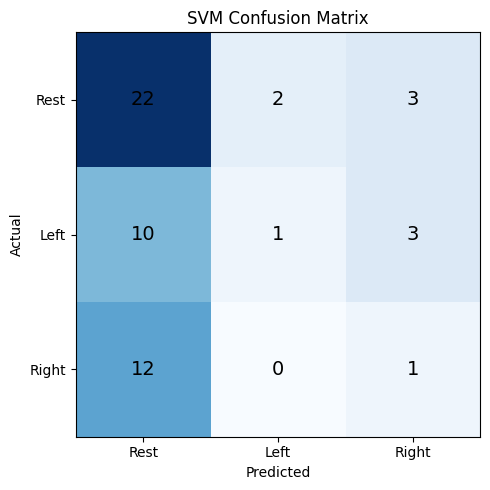

Confusion matrix saved!


In [28]:
# Confusion matrix — shows where the model gets confused
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(['Rest', 'Left', 'Right'])
ax.set_yticklabels(['Rest', 'Left', 'Right'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('SVM Confusion Matrix')
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha='center', va='center', 
                color='black', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/plots/svm_confusion_matrix.png')
plt.show()
print("Confusion matrix saved!")